In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Environment ready is ready")

Environment ready is ready


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print("Imports are ok")

Imports are ok


In [3]:
df = pd.read_csv('../data/raw/ae_weekly_raw.csv')

print(df.shape)
print(df.dtypes)
print(df.head())

(41218, 14)
WeekEndingDate                     int64
Country                              str
HBT                                  str
TreatmentLocation                    str
DepartmentType                       str
AttendanceCategory                   str
NumberOfAttendancesEpisode         int64
NumberWithin4HoursEpisode          int64
NumberOver4HoursEpisode            int64
PercentageWithin4HoursEpisode    float64
NumberOver8HoursEpisode            int64
PercentageOver8HoursEpisode      float64
NumberOver12HoursEpisode           int64
PercentageOver12HoursEpisode     float64
dtype: object
   WeekEndingDate    Country        HBT TreatmentLocation DepartmentType  \
0        20150222  S92000003  S08000015             A210H         Type 1   
1        20150222  S92000003  S08000015             A210H         Type 1   
2        20150222  S92000003  S08000015             A111H         Type 1   
3        20150222  S92000003  S08000015             A111H         Type 1   
4        20150222  S

In [4]:
# Fix the date column
df['WeekEndingDate'] = pd.to_datetime(df['WeekEndingDate'], format='%Y%m%d')
# Keeping only one department 
df = df[
    (df['DepartmentType'] == 'Type 1') &
    (df['AttendanceCategory'] == 'Unplanned')
].copy()

print(f"Rows after filter: {df.shape[0]}")
print(f"Unique health boards: {df['HBT'].nunique()}")
print(f"Date range: {df['WeekEndingDate'].min()} → {df['WeekEndingDate'].max()}")

Rows after filter: 17609
Unique health boards: 14
Date range: 2015-02-22 00:00:00 → 2026-05-10 00:00:00


In [5]:
weekly = df.groupby(['WeekEndingDate', 'HBT']).agg(
    Attendances      = ('NumberOfAttendancesEpisode', 'sum'),
    Within4Hours     = ('NumberWithin4HoursEpisode', 'sum'),
    Over4Hours       = ('NumberOver4HoursEpisode', 'sum'),
    Over8Hours       = ('NumberOver8HoursEpisode', 'sum'),
    Over12Hours      = ('NumberOver12HoursEpisode', 'sum'),
).reset_index()

# Derive your target variable
weekly['BreachRate'] = weekly['Over4Hours'] / weekly['Attendances']
weekly['Within4HoursPct'] = weekly['Within4Hours'] / weekly['Attendances']

# Flag: did the board miss the 95% target this week?
weekly['BreachedTarget'] = (weekly['Within4HoursPct'] < 0.95).astype(int)

print(weekly.shape)
print(weekly.head(10))

(8204, 10)
  WeekEndingDate        HBT  Attendances  Within4Hours  Over4Hours  \
0     2015-02-22  S08000015         2161          1739         422   
1     2015-02-22  S08000016          517           463          54   
2     2015-02-22  S08000017          800           763          37   
3     2015-02-22  S08000019         1095          1053          42   
4     2015-02-22  S08000020         1877          1681         196   
5     2015-02-22  S08000022          950           903          47   
6     2015-02-22  S08000024         3916          3700         216   
7     2015-02-22  S08000025           91            85           6   
8     2015-02-22  S08000026          146           142           4   
9     2015-02-22  S08000028          113           110           3   

   Over8Hours  Over12Hours  BreachRate  Within4HoursPct  BreachedTarget  
0          52            4    0.195280         0.804720               1  
1           1            0    0.104449         0.895551               

In [6]:
hb_names = {
    'S08000015': 'Ayrshire & Arran',
    'S08000016': 'Borders',
    'S08000017': 'Dumfries & Galloway',
    'S08000019': 'Forth Valley',
    'S08000020': 'Grampian',
    'S08000022': 'Highland',
    'S08000024': 'Lothian',
    'S08000025': 'Orkney',
    'S08000026': 'Shetland',
    'S08000028': 'Western Isles',
    'S08000029': 'Fife',
    'S08000030': 'Tayside',
    'S08000031': 'Greater Glasgow & Clyde',
    'S08000032': 'Lanarkshire',
}

weekly['BoardName'] = weekly['HBT'].map(hb_names)

# Check for any unmapped codes
unmapped = weekly[weekly['BoardName'].isna()]['HBT'].unique()
print(f"Unmapped codes: {unmapped}")

Unmapped codes: <ArrowStringArray>
[]
Length: 0, dtype: str


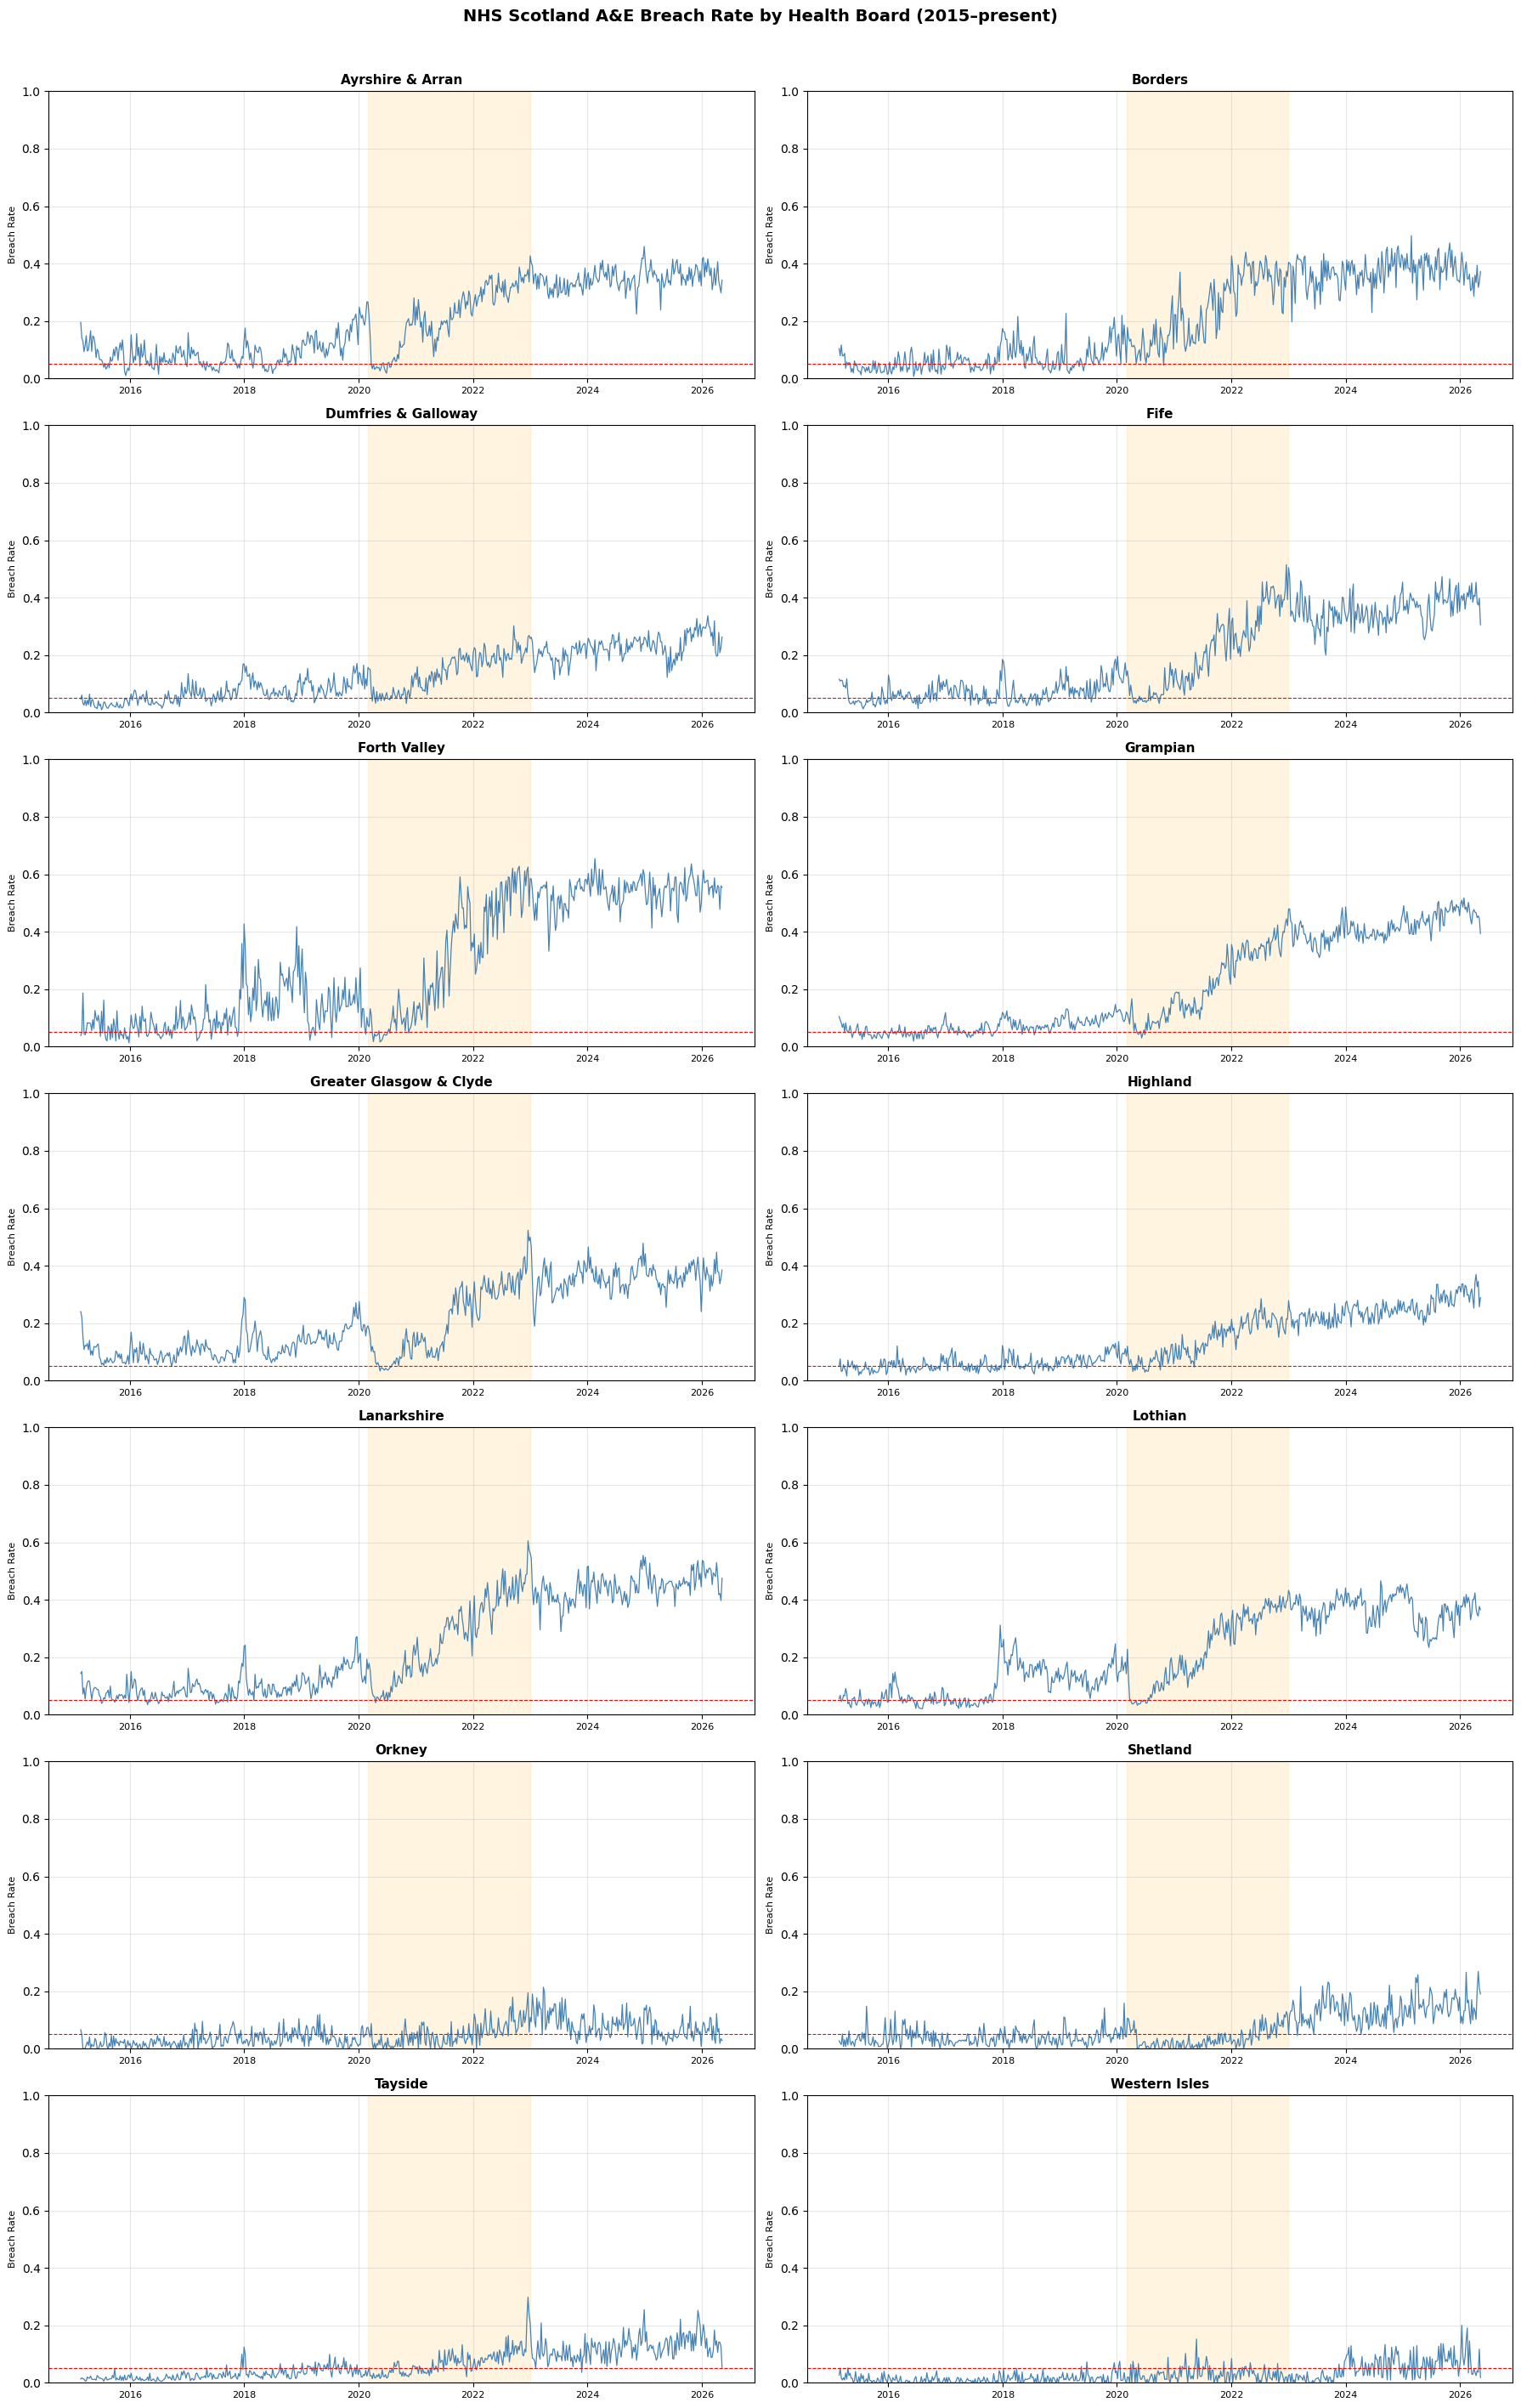

Plot saved


In [8]:
boards = weekly['BoardName'].dropna().unique()
boards_sorted = sorted(boards)

fig, axes = plt.subplots(7, 2, figsize=(18, 28))
axes = axes.flatten()

for i, board in enumerate(boards_sorted):
    ax = axes[i]
    data = weekly[weekly['BoardName'] == board].sort_values('WeekEndingDate')
    
    ax.plot(data['WeekEndingDate'], data['BreachRate'], linewidth=0.9, color='steelblue')
    ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8, label='5% breach threshold')
    
    # Shade COVID era
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2022-12-31'),
               alpha=0.12, color='orange', label='COVID era')
    
    ax.set_title(board, fontsize=11, fontweight='bold')
    ax.set_ylabel('Breach Rate', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', labelsize=8)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

# Hide the last empty subplot if odd number of boards
for j in range(len(boards_sorted), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('NHS Scotland A&E Breach Rate by Health Board (2015–present)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/breach_rate_all_boards.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [9]:
weekly.to_csv('../data/processed/ae_weekly_clean.csv', index=False)
print(f"Saved {len(weekly)} rows to data/processed/ae_weekly_clean.csv ")

Saved 8204 rows to data/processed/ae_weekly_clean.csv 


In [16]:
summary = weekly.groupby('BoardName').agg(
    Weeks           = ('WeekEndingDate', 'count'),
    AvgBreachRate   = ('BreachRate', 'mean'),
    MaxBreachRate   = ('BreachRate', 'max'),
    PctWeeksBreached= ('BreachedTarget', 'mean'),
    AvgAttendances  = ('Attendances', 'mean'),
).round(3).sort_values('AvgBreachRate', ascending=False)

print(summary.to_string())

                         Weeks  AvgBreachRate  MaxBreachRate  PctWeeksBreached  AvgAttendances
BoardName                                                                                     
Forth Valley               586          0.289          0.655             0.887        1161.101
Lanarkshire                586          0.245          0.605             0.959        3793.896
Greater Glasgow & Clyde    586          0.213          0.523             0.981        6486.507
Lothian                    586          0.211          0.466             0.846        4302.203
Grampian                   586          0.210          0.517             0.865        1865.619
Borders                    586          0.201          0.498             0.805         574.626
Ayrshire & Arran           586          0.199          0.460             0.889        1939.220
Fife                       586          0.190          0.515             0.811        1245.218
Highland                   586          0.135     

In [12]:
all_weeks = pd.date_range(
    start=weekly['WeekEndingDate'].min(),
    end=weekly['WeekEndingDate'].max(),
    freq='W-SUN'
)

print(f"Expected weeks in full series: {len(all_weeks)}")
print()

for board in sorted(weekly['BoardName'].dropna().unique()):
    board_weeks = weekly[weekly['BoardName'] == board]['WeekEndingDate']
    missing = len(all_weeks) - len(board_weeks)
    if missing > 0:
        print(f"!!! {board}: {missing} missing weeks")
    else:
        print(f" {board}: complete")

Expected weeks in full series: 586

 Ayrshire & Arran: complete
 Borders: complete
 Dumfries & Galloway: complete
 Fife: complete
 Forth Valley: complete
 Grampian: complete
 Greater Glasgow & Clyde: complete
 Highland: complete
 Lanarkshire: complete
 Lothian: complete
 Orkney: complete
 Shetland: complete
 Tayside: complete
 Western Isles: complete


In [13]:
island_boards = ['Orkney', 'Shetland', 'Western Isles']

mainland = weekly[~weekly['BoardName'].isin(island_boards)].copy()
islands  = weekly[weekly['BoardName'].isin(island_boards)].copy()

print(f"Mainland boards: {mainland['BoardName'].nunique()}")
print(f"Island boards:   {islands['BoardName'].nunique()}")
print(f"Mainland rows:   {len(mainland)}")

Mainland boards: 11
Island boards:   3
Mainland rows:   6446


In [14]:
def period(date):
    if date < pd.Timestamp('2020-03-01'):
        return 'Pre-COVID (2015–2020)'
    elif date <= pd.Timestamp('2022-12-31'):
        return 'COVID Era (2020–2022)'
    else:
        return 'Post-COVID (2023–present)'

mainland['Period'] = mainland['WeekEndingDate'].apply(period)

period_summary = mainland.groupby(['BoardName', 'Period'])['BreachRate'].mean().unstack()
period_summary = period_summary[['Pre-COVID (2015–2020)', 'COVID Era (2020–2022)', 'Post-COVID (2023–present)']]
period_summary = period_summary.round(3).sort_values('Post-COVID (2023–present)', ascending=False)

print(period_summary.to_string())

Period                   Pre-COVID (2015–2020)  COVID Era (2020–2022)  Post-COVID (2023–present)
BoardName                                                                                       
Forth Valley                             0.117                  0.297                      0.539
Lanarkshire                              0.096                  0.269                      0.446
Grampian                                 0.068                  0.215                      0.419
Borders                                  0.066                  0.238                      0.372
Lothian                                  0.097                  0.227                      0.366
Greater Glasgow & Clyde                  0.118                  0.208                      0.359
Fife                                     0.069                  0.205                      0.358
Ayrshire & Arran                         0.090                  0.213                      0.349
Highland                      

In [15]:
mainland.drop(columns='Period').to_csv('../data/processed/ae_mainland_clean.csv', index=False)
print(f"Saved {len(mainland)} rows ")

Saved 6446 rows 


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/ae_mainland_clean.csv', parse_dates=['WeekEndingDate'])

# Calendar features
df['WeekOfYear']      = df['WeekEndingDate'].dt.isocalendar().week.astype(int)
df['Month']           = df['WeekEndingDate'].dt.month
df['Year']            = df['WeekEndingDate'].dt.year

# Flu season: October–March = 1
df['FluSeasonFlag']   = df['Month'].isin([10, 11, 12, 1, 2, 3]).astype(int)

# Winter: Dec–Feb (coldest, highest pressure)
df['WinterFlag']      = df['Month'].isin([12, 1, 2]).astype(int)

# Christmas weeks
df['ChristmasWeek']   = df['WeekOfYear'].isin([51, 52, 1]).astype(int)

print(df[['WeekEndingDate','WeekOfYear','Month','FluSeasonFlag','WinterFlag','ChristmasWeek']].head(20))

   WeekEndingDate  WeekOfYear  Month  FluSeasonFlag  WinterFlag  ChristmasWeek
0      2015-02-22           8      2              1           1              0
1      2015-02-22           8      2              1           1              0
2      2015-02-22           8      2              1           1              0
3      2015-02-22           8      2              1           1              0
4      2015-02-22           8      2              1           1              0
5      2015-02-22           8      2              1           1              0
6      2015-02-22           8      2              1           1              0
7      2015-02-22           8      2              1           1              0
8      2015-02-22           8      2              1           1              0
9      2015-02-22           8      2              1           1              0
10     2015-02-22           8      2              1           1              0
11     2015-03-01           9      3              1 

In [2]:
def covid_phase(date):
    if date < pd.Timestamp('2020-03-16'):      # First Scottish lockdown
        return 0  # Pre-COVID
    elif date <= pd.Timestamp('2020-09-14'):   # First lockdown + immediate aftermath
        return 1  # Lockdown
    elif date <= pd.Timestamp('2021-04-26'):   # Restrictions easing Phase 1-2
        return 2  # Reopening
    elif date <= pd.Timestamp('2022-03-21'):   # Living with COVID, before restrictions fully lifted
        return 3  # Endemic transition
    else:
        return 0  # Back to normal (structurally different, but no longer COVID policy)

df['CovidPhase']      = df['WeekEndingDate'].apply(covid_phase)
df['CovidEra']        = (df['CovidPhase'] > 0).astype(int)
df['PostCovidStress'] = (df['WeekEndingDate'] >= pd.Timestamp('2022-04-01')).astype(int)
df['VaxRollout']      = (df['WeekEndingDate'] >= pd.Timestamp('2020-12-08')).astype(int)

print(df['CovidPhase'].value_counts().sort_index())
print(df[['WeekEndingDate','CovidPhase','CovidEra','PostCovidStress']].drop_duplicates('CovidPhase'))

CovidPhase
0    5291
1     286
2     352
3     517
Name: count, dtype: int64
     WeekEndingDate  CovidPhase  CovidEra  PostCovidStress
0        2015-02-22           0         0                0
2915     2020-03-22           1         1                0
3201     2020-09-20           2         1                0
3553     2021-05-02           3         1                0


In [3]:
# Sort correctly before computing lags
df = df.sort_values(['HBT', 'WeekEndingDate']).reset_index(drop=True)

for board_code, group in df.groupby('HBT'):
    idx = group.index
    
    # Lag features
    df.loc[idx, 'Lag1_BreachRate']  = group['BreachRate'].shift(1)
    df.loc[idx, 'Lag2_BreachRate']  = group['BreachRate'].shift(2)
    df.loc[idx, 'Lag4_BreachRate']  = group['BreachRate'].shift(4)
    df.loc[idx, 'Lag8_BreachRate']  = group['BreachRate'].shift(8)
    
    df.loc[idx, 'Lag1_Attendances'] = group['Attendances'].shift(1)
    df.loc[idx, 'Lag4_Attendances'] = group['Attendances'].shift(4)

    # Rolling stats (on BreachRate)
    df.loc[idx, 'RollingMean4W']    = group['BreachRate'].shift(1).rolling(4).mean()
    df.loc[idx, 'RollingMean8W']    = group['BreachRate'].shift(1).rolling(8).mean()
    df.loc[idx, 'RollingStd4W']     = group['BreachRate'].shift(1).rolling(4).std()
    df.loc[idx, 'RollingMax4W']     = group['BreachRate'].shift(1).rolling(4).max()

    # Trend: is breach rate rising?
    df.loc[idx, 'BreachRateDelta']  = group['BreachRate'].shift(1).diff(4)

print(f"NaNs from lag features (expected for first few weeks per board):")
lag_cols = ['Lag1_BreachRate','Lag4_BreachRate','RollingMean4W','RollingStd4W']
print(df[lag_cols].isna().sum())

NaNs from lag features (expected for first few weeks per board):
Lag1_BreachRate    11
Lag4_BreachRate    44
RollingMean4W      44
RollingStd4W       44
dtype: int64


In [4]:
# SIMD deprivation score (2020) — higher score = more deprived
# Source: gov.scot/collections/scottish-index-of-multiple-deprivation-2020
simd = {
    'S08000015': 37.2,  # Ayrshire & Arran
    'S08000016': 20.1,  # Borders
    'S08000017': 24.3,  # Dumfries & Galloway
    'S08000019': 28.4,  # Forth Valley
    'S08000020': 26.1,  # Grampian
    'S08000022': 22.8,  # Highland
    'S08000024': 32.5,  # Lothian
    'S08000029': 33.1,  # Fife
    'S08000030': 29.7,  # Tayside
    'S08000031': 42.6,  # Greater Glasgow & Clyde
    'S08000032': 38.9,  # Lanarkshire
}

# Urban flag
urban_boards = ['S08000024', 'S08000031', 'S08000032', 'S08000030', 'S08000020']

# Approx population served (thousands) — from NRS Scotland 2022 estimates
population = {
    'S08000015': 369,
    'S08000016': 115,
    'S08000017': 148,
    'S08000019': 307,
    'S08000020': 585,
    'S08000022': 321,
    'S08000024': 919,
    'S08000029': 373,
    'S08000030': 416,
    'S08000031': 1183,
    'S08000032': 661,
}

df['SIMDScore']    = df['HBT'].map(simd)
df['IsUrban']      = df['HBT'].isin(urban_boards).astype(int)
df['PopulationK']  = df['HBT'].map(population)
df['AttendancesPer1000'] = df['Attendances'] / df['PopulationK']

print(df[['BoardName','SIMDScore','IsUrban','PopulationK','AttendancesPer1000']].drop_duplicates('BoardName').sort_values('SIMDScore', ascending=False))

                    BoardName  SIMDScore  IsUrban  PopulationK  \
5274  Greater Glasgow & Clyde       42.6        1         1183   
5860              Lanarkshire       38.9        1          661   
0            Ayrshire & Arran       37.2        0          369   
4102                     Fife       33.1        0          373   
3516                  Lothian       32.5        1          919   
4688                  Tayside       29.7        1          416   
1758             Forth Valley       28.4        0          307   
2344                 Grampian       26.1        1          585   
1172      Dumfries & Galloway       24.3        0          148   
2930                 Highland       22.8        0          321   
586                   Borders       20.1        0          115   

      AttendancesPer1000  
5274            6.406593  
5860            5.518911  
0               5.856369  
4102            3.442359  
3516            4.261153  
4688            3.211538  
1758            3.

In [5]:
df.to_csv('../data/processed/ae_features.csv', index=False)

print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"\nAll columns:")
for col in df.columns:
    print(f"  {col}")

Rows: 6446
Columns: 36

All columns:
  WeekEndingDate
  HBT
  Attendances
  Within4Hours
  Over4Hours
  Over8Hours
  Over12Hours
  BreachRate
  Within4HoursPct
  BreachedTarget
  BoardName
  WeekOfYear
  Month
  Year
  FluSeasonFlag
  WinterFlag
  ChristmasWeek
  CovidPhase
  CovidEra
  PostCovidStress
  VaxRollout
  Lag1_BreachRate
  Lag2_BreachRate
  Lag4_BreachRate
  Lag8_BreachRate
  Lag1_Attendances
  Lag4_Attendances
  RollingMean4W
  RollingMean8W
  RollingStd4W
  RollingMax4W
  BreachRateDelta
  SIMDScore
  IsUrban
  PopulationK
  AttendancesPer1000


In [1]:
import pandas as pd
import time
from pytrends.request import TrendReq

# Pass browser-like headers to avoid 429 rate limiting
pytrends = TrendReq(
    hl='en-GB',
    tz=0,
    timeout=(10, 25),
    retries=2,
    backoff_factor=0.5,
    requests_args={
        'headers': {
            'User-Agent': (
                'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                'AppleWebKit/537.36 (KHTML, like Gecko) '
                'Chrome/124.0.0.0 Safari/537.36'
            ),
            'Accept-Language': 'en-GB,en;q=0.9',
            'Accept-Encoding': 'gzip, deflate, br',
        }
    }
)

# Pull one keyword at a time with a generous sleep between each
keywords = ['flu symptoms', 'sore throat', 'fever', 'NHS 24']
all_trends = []

for kw in keywords:
    try:
        pytrends.build_payload(
            [kw],
            cat=0,
            timeframe='2015-01-01 2026-05-01',
            geo='GB-SCT'
        )
        time.sleep(5)   # wait before fetching — critical
        data = pytrends.interest_over_time()

        if not data.empty:
            data = data.drop(columns='isPartial', errors='ignore')
            data.columns = [kw]
            all_trends.append(data)
            print(f"✓  {kw}: {len(data)} weeks")
        else:
            print(f"⚠️  {kw}: empty response")

    except Exception as e:
        print(f"✗  {kw}: {e}")

    time.sleep(10)   # longer pause between keywords

print(f"\nSuccessful pulls: {len(all_trends)} / {len(keywords)}")

✓  flu symptoms: 137 weeks
✓  sore throat: 137 weeks
✓  fever: 137 weeks
✓  NHS 24: 137 weeks

Successful pulls: 4 / 4


In [2]:
if len(all_trends) == 0:
    print("No trends data — check Cell 20 errors above")
else:
    trends_df = pd.concat(all_trends, axis=1).reset_index()
    trends_df.rename(columns={'date': 'WeekEndingDate'}, inplace=True)
    trends_df['WeekEndingDate'] = pd.to_datetime(trends_df['WeekEndingDate'])

    # Composite index: mean of whichever keywords succeeded
    successful_kws = [kw for kw in keywords if kw in trends_df.columns]
    trends_df['FluSearchIndex'] = trends_df[successful_kws].mean(axis=1)

    print(f"Date range: {trends_df['WeekEndingDate'].min()} → {trends_df['WeekEndingDate'].max()}")
    print(f"Weeks: {len(trends_df)}")
    print(trends_df[['WeekEndingDate', 'FluSearchIndex']].head(10))

    # Save separately so you don't have to re-pull
    trends_df.to_csv('../data/processed/flu_search_index.csv', index=False)
    print("\nSaved to data/processed/flu_search_index.csv ✓")

Date range: 2015-01-01 00:00:00 → 2026-05-01 00:00:00
Weeks: 137
  WeekEndingDate  FluSearchIndex
0     2015-01-01           29.25
1     2015-02-01           30.25
2     2015-03-01           31.50
3     2015-04-01           27.25
4     2015-05-01           23.00
5     2015-06-01           25.25
6     2015-07-01           23.50
7     2015-08-01           23.25
8     2015-09-01           25.50
9     2015-10-01           25.25

Saved to data/processed/flu_search_index.csv ✓


In [3]:
df = pd.read_csv('../data/processed/ae_features.csv', parse_dates=['WeekEndingDate'])
trends_df = pd.read_csv('../data/processed/flu_search_index.csv', parse_dates=['WeekEndingDate'])

# Align week endings — both should be Sunday but may differ by a day
df['WeekKey']       = df['WeekEndingDate'].dt.to_period('W').dt.end_time.dt.normalize()
trends_df['WeekKey'] = trends_df['WeekEndingDate'].dt.to_period('W').dt.end_time.dt.normalize()

df = df.merge(
    trends_df[['WeekKey', 'FluSearchIndex']],
    on='WeekKey',
    how='left'
)
df.drop(columns='WeekKey', inplace=True)

print(f"FluSearchIndex NaNs: {df['FluSearchIndex'].isna().sum()}")
print(f"Non-null weeks: {df['FluSearchIndex'].notna().sum()}")
print(df[['WeekEndingDate', 'BoardName', 'FluSearchIndex']].dropna().head(10))

df.to_csv('../data/processed/ae_features.csv', index=False)
print("\nae_features.csv updated ✓")

FluSearchIndex NaNs: 4961
Non-null weeks: 1485
   WeekEndingDate         BoardName  FluSearchIndex
1      2015-03-01  Ayrshire & Arran           31.50
6      2015-04-05  Ayrshire & Arran           27.25
10     2015-05-03  Ayrshire & Arran           23.00
15     2015-06-07  Ayrshire & Arran           25.25
19     2015-07-05  Ayrshire & Arran           23.50
23     2015-08-02  Ayrshire & Arran           23.25
28     2015-09-06  Ayrshire & Arran           25.50
32     2015-10-04  Ayrshire & Arran           25.25
36     2015-11-01  Ayrshire & Arran           26.25
41     2015-12-06  Ayrshire & Arran           30.75

ae_features.csv updated ✓
